In [23]:
import pandas as pd
df = pd.read_csv('/kaggle/input/datasets/harshitaaja/dataset/output.csv')
df.head(3)

,lp,Vessel_Speed,GTT,GT_rpm,CPP_T_stbd,CPP_T_port,Q_port,rpm_port,Q_stdb,rpm_stbd,...,rps_prop_stbd,Kt_port,rps_prop_port,Q_prop_port,Q_prop_stbd,Kkt,Kkq,Khull,KMcompr,KMturb
0,1.1379,3,7320.4,1384.7,9.4762,9.4762,42509,60.638,42509,60.638,...,1.01060,0.019494,1.01060,28193,28193,0.9,1.1,1.0,0.95,0.975
1,2.0883,6,4916.0,1348.7,22.8980,22.8980,58175,59.061,58175,59.061,...,0.98435,0.046701,0.98435,40853,40853,0.9,1.1,1.0,0.95,0.975
2,3.1438,9,9450.7,1386.8,58.4620,58.4620,107900,60.728,107900,60.728,...,1.01210,0.110680,1.01210,84274,84274,0.9,1.1,1.0,0.95,0.975


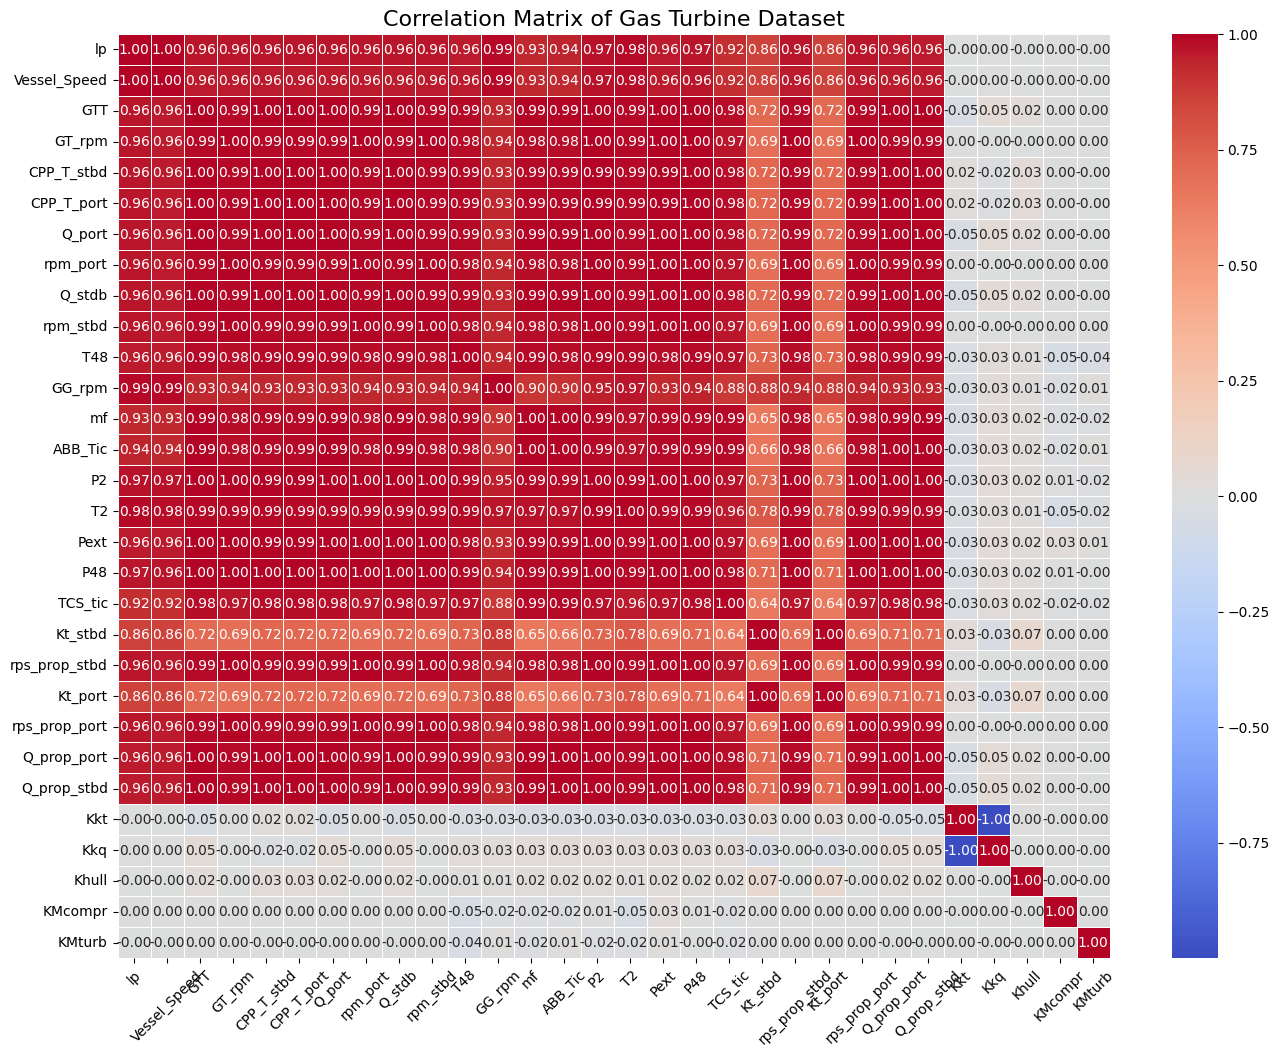

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation
corr_matrix = df.corr()

plt.figure(figsize=(16,12))

sns.heatmap(
    corr_matrix,
    annot=True,          # show values inside boxes
    fmt=".2f",           # show 2 decimal points
    cmap="coolwarm",     # better color contrast
    linewidths=0.5
)

plt.title("Correlation Matrix of Gas Turbine Dataset", fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

# LINEAR REGRESSION

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
df = pd.read_csv('/kaggle/input/datasets/harshitaaja/dataset/output.csv')


df.columns = df.columns.str.replace('\xa0', '').str.strip()

if "index" in df.columns:
    df = df.drop(columns=["index"])


df = df.loc[:, df.nunique() > 1]

df = df.drop(columns=[
    "Vessel_Speed",      # perfect duplicate of lp
    "CPP_T_port",        # perfect duplicate of CPP_T_stbd
    "Q_stdb",            # perfect duplicate of Q_port
    "rpm_stbd",          # perfect duplicate of rpm_port
    "Kt_port",           # perfect duplicate of Kt_stbd
    "rps_prop_port",     # perfect duplicate of rps_prop_stbd
    "Q_prop_stbd",       # perfect duplicate of Q_prop_port
    "Kkq",               # derived directly from Kkt (1 - Kkt = Kkq - 1)
])


targets = [
    "Kkt",
    "Khull",
    "KMcompr",
    "KMturb"
]

X = df.drop(columns=targets)
y = df[targets]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

train_mae  = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2   = r2_score(y_train, y_train_pred)

test_mae  = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2   = r2_score(y_test, y_test_pred)

print("MODEL: Linear Regression")
print("\nTRAIN RESULTS")
print("R2:", train_r2)
print("MAE:", train_mae)
print("RMSE:", train_rmse)
print("\nTEST RESULTS")
print("R2:", test_r2)
print("MAE:", test_mae)
print("RMSE:", test_rmse)


MODEL: Linear Regression

TRAIN RESULTS
R2: 0.8007672492780935
MAE: 0.011873275742001773
RMSE: 0.0231331259030639

TEST RESULTS
R2: 0.8009588359565549
MAE: 0.011872498668961184
RMSE: 0.023128275794829057


In [26]:
coefficients = pd.DataFrame(
    model.coef_,
    columns=X.columns,
    index=targets
)
print("\nModel Coefficients:")
print(coefficients)


Model Coefficients:
               lp       GTT     GT_rpm  CPP_T_stbd    Q_port  rpm_port  \
Kkt      0.102532 -0.330476 -12.775848   -0.087985 -6.940509  0.974717   
Khull   -0.787930  0.821004 -14.906951    0.182351  1.941398 -6.803280   
KMcompr  0.035351 -0.001322  -0.925854   -0.013157 -1.012621  0.158952   
KMturb   0.002310  0.514951  -1.245050   -0.002659 -0.317389 -0.069920   

              T48    GG_rpm        mf   ABB_Tic        P2        T2      Pext  \
Kkt      0.101558  0.018877  0.512495 -0.049690 -0.243218 -0.191246  0.290238   
Khull   -0.242206 -0.393588 -1.100983  0.416473  0.801924  0.478501 -0.377933   
KMcompr  0.070019 -0.051500 -0.344286 -0.094189  0.011785 -0.337960 -0.480293   
KMturb  -0.204214  0.026200  0.096006  0.021103 -0.188819  0.107526 -0.053869   

              P48   TCS_tic   Kt_stbd  rps_prop_stbd  Q_prop_port  
Kkt     -0.570845 -0.014543  0.177433      12.069124     7.015055  
Khull    0.600777  0.114421  0.237980      21.779008    -2.743028 

# POLYNOMIAL REGRESSION

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


df = pd.read_csv('/kaggle/input/datasets/harshitaaja/dataset/output.csv')

df.columns = df.columns.str.replace('\xa0', '').str.strip()


if "index" in df.columns:
    df = df.drop(columns=["index"])


df = df.loc[:, df.nunique() > 1]

df = df.drop(columns=[
    "Vessel_Speed",      # perfect duplicate of lp
    "CPP_T_port",        # perfect duplicate of CPP_T_stbd
    "Q_stdb",            # perfect duplicate of Q_port
    "rpm_stbd",          # perfect duplicate of rpm_port
    "Kt_port",           # perfect duplicate of Kt_stbd
    "rps_prop_port",     # perfect duplicate of rps_prop_stbd
    "Q_prop_stbd",       # perfect duplicate of Q_prop_port
    "Kkq",               # derived directly from Kkt (1 - Kkt = Kkq - 1)
])


targets = [
    "Kkt",
    "Khull",
    "KMcompr",
    "KMturb"
]

X = df.drop(columns=targets)
y = df[targets]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

best_degree = 1
best_rmse   = float('inf')

for degree in [1, 2, 3]:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly  = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    train_pred = model.predict(X_train_poly)
    test_pred  = model.predict(X_test_poly)

    train_r2   = r2_score(y_train, train_pred)
    train_mae  = mean_absolute_error(y_train, train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_r2    = r2_score(y_test, test_pred)
    test_mae   = mean_absolute_error(y_test, test_pred)
    test_rmse  = np.sqrt(mean_squared_error(y_test, test_pred))

    print(f"\n{'='*35}")
    print(f"Polynomial Degree: {degree}")
    print(f"{'='*35}")
    print(f"TRAIN → R²: {train_r2:.4f} | MAE: {train_mae:.6f} | RMSE: {train_rmse:.6f}")
    print(f"TEST  → R²: {test_r2:.4f} | MAE: {test_mae:.6f} | RMSE: {test_rmse:.6f}")

    if test_rmse < best_rmse:
        best_rmse   = test_rmse
        best_degree = degree

print(f"\n Optimal Degree: {best_degree} (lowest Test RMSE: {best_rmse:.6f})")



Polynomial Degree: 1
TRAIN → R²: 0.8008 | MAE: 0.011873 | RMSE: 0.023133
TEST  → R²: 0.8010 | MAE: 0.011872 | RMSE: 0.023128

Polynomial Degree: 2
TRAIN → R²: 0.9617 | MAE: 0.005006 | RMSE: 0.010713
TEST  → R²: 0.9616 | MAE: 0.005020 | RMSE: 0.010740

Polynomial Degree: 3
TRAIN → R²: 0.9300 | MAE: 0.005944 | RMSE: 0.013877
TEST  → R²: 0.9299 | MAE: 0.005961 | RMSE: 0.013906

✅ Optimal Degree: 2 (lowest Test RMSE: 0.010740)


# MULTIPLE LINEAR REGRESSION

In [ ]:


import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


df = pd.read_csv('/kaggle/input/datasets/harshitaaja/dataset/output.csv')


df.columns = df.columns.str.replace('\xa0', '').str.strip()

if "index" in df.columns:
    df = df.drop(columns=["index"])

df = df.loc[:, df.nunique() > 1]


df = df.drop(columns=[
    "Vessel_Speed",      # perfect duplicate of lp
    "CPP_T_port",        # perfect duplicate of CPP_T_stbd
    "Q_stdb",            # perfect duplicate of Q_port
    "rpm_stbd",          # perfect duplicate of rpm_port
    "Kt_port",           # perfect duplicate of Kt_stbd
    "rps_prop_port",     # perfect duplicate of rps_prop_stbd
    "Q_prop_stbd",       # perfect duplicate of Q_prop_port
    "Kkq",               # derived directly from Kkt (1 - Kkt = Kkq - 1)
])


targets = [
    "Kkt",
    "Khull",
    "KMcompr",
    "KMturb"
]

X = df.drop(columns=targets)
y = df[targets]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

train_pred = model.predict(X_train)
test_pred  = model.predict(X_test)

train_mae  = mean_absolute_error(y_train, train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
train_r2   = r2_score(y_train, train_pred)

test_mae  = mean_absolute_error(y_test, test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
test_r2   = r2_score(y_test, test_pred)

print("MODEL: Multiple Linear Regression")
print("\nTRAIN RESULTS")
print("R2:", train_r2)
print("MAE:", train_mae)
print("RMSE:", train_rmse)
print("\nTEST RESULTS")
print("R2:", test_r2)
print("MAE:", test_mae)
print("RMSE:", test_rmse)


MODEL: Multiple Linear Regression

TRAIN RESULTS
R2: 0.8007672492780908
MAE: 0.01187327574200178
RMSE: 0.023133125903064194

TEST RESULTS
R2: 0.8009588359565546
MAE: 0.011872498668961269
RMSE: 0.023128275794829078


In [30]:
coefficients = pd.DataFrame(
    model.coef_,
    columns=X.columns,
    index=targets
)
print("\nModel Coefficients:")
print(coefficients)



Model Coefficients:
               lp           GTT    GT_rpm  CPP_T_stbd    Q_port  rpm_port  \
Kkt      0.039046 -1.360332e-05 -0.016588   -0.000436 -0.000025  0.028901   
Khull   -0.300056  3.379486e-05 -0.019355    0.000904  0.000007 -0.201724   
KMcompr  0.013462 -5.442148e-08 -0.001202   -0.000065 -0.000004  0.004713   
KMturb   0.000880  2.119683e-05 -0.001617   -0.000013 -0.000001 -0.002073   

              T48    GG_rpm        mf   ABB_Tic        P2        T2  \
Kkt      0.000555  0.000017  0.937054 -0.001814 -0.043451 -0.002545   
Khull   -0.001323 -0.000356 -2.013055  0.015203  0.143264  0.006368   
KMcompr  0.000383 -0.000047 -0.629498 -0.003438  0.002105 -0.004497   
KMturb  -0.001116  0.000024  0.175539  0.000770 -0.033733  0.001431   

              Pext       P48   TCS_tic   Kt_stbd  rps_prop_stbd   Q_prop_port  
Kkt      26.551854 -0.501757 -0.000519  2.802043      21.471769  2.588096e-05  
Khull   -34.574434  0.528066  0.004086  3.758207      38.746294 -1.011998e-05

# LASO

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


df = pd.read_csv('/kaggle/input/datasets/harshitaaja/dataset/output.csv')


df.columns = df.columns.str.replace('\xa0', '').str.strip()
if "index" in df.columns:
    df = df.drop(columns=["index"])


df = df.loc[:, df.nunique() > 1]


df = df.drop(columns=[
    "Vessel_Speed",      # perfect duplicate of lp
    "CPP_T_port",        # perfect duplicate of CPP_T_stbd
    "Q_stdb",            # perfect duplicate of Q_port
    "rpm_stbd",          # perfect duplicate of rpm_port
    "Kt_port",           # perfect duplicate of Kt_stbd
    "rps_prop_port",     # perfect duplicate of rps_prop_stbd
    "Q_prop_stbd",       # perfect duplicate of Q_prop_port
    "Kkq",               # derived directly from Kkt (1 - Kkt = Kkq - 1)
])


targets = [
    "Kkt",
    "Khull",
    "KMcompr",
    "KMturb"
]

X = df.drop(columns=targets)
y = df[targets]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

alphas = [0.0001, 0.001, 0.01, 0.1, 10]

for alpha in alphas:
    print(f"\n==========================")
    print(f"Alpha: {alpha}")
    print(f"==========================")

    model = MultiOutputRegressor(Lasso(alpha=alpha, max_iter=20000))
    model.fit(X_train_s, y_train)

    train_pred = model.predict(X_train_s)
    test_pred  = model.predict(X_test_s)

    print("TRAIN RESULTS")
    print("R2:",   r2_score(y_train, train_pred))
    print("MAE:",  mean_absolute_error(y_train, train_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_train, train_pred)))
    print("\nTEST RESULTS")
    print("R2:",   r2_score(y_test, test_pred))
    print("MAE:",  mean_absolute_error(y_test, test_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, test_pred)))



Alpha: 0.0001


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.137e+00, tolerance: 1.386e-01
  model = cd_fast.enet_coordinate_descent(


TRAIN RESULTS
R2: 0.4624501372415507
MAE: 0.01624925139777848
RMSE: 0.02582091549538207

TEST RESULTS
R2: 0.46331583628724293
MAE: 0.01624646391045126
RMSE: 0.025821974160307654

Alpha: 0.001
TRAIN RESULTS
R2: 0.029174948500430398
MAE: 0.024364357995738172
RMSE: 0.03441746765947721

TEST RESULTS
R2: 0.029340088225026595
MAE: 0.024373900049852112
RMSE: 0.034436415077476634

Alpha: 0.01
TRAIN RESULTS
R2: 0.0
MAE: 0.02499846136150675
RMSE: 0.03555726084470542

TEST RESULTS
R2: -2.900414092565917e-06
MAE: 0.02500920297145287
RMSE: 0.03558373480672413

Alpha: 0.1
TRAIN RESULTS
R2: 0.0
MAE: 0.02499846136150675
RMSE: 0.03555726084470542

TEST RESULTS
R2: -2.900414092565917e-06
MAE: 0.02500920297145287
RMSE: 0.03558373480672413

Alpha: 10
TRAIN RESULTS
R2: 0.0
MAE: 0.02499846136150675
RMSE: 0.03555726084470542

TEST RESULTS
R2: -2.900414092565917e-06
MAE: 0.02500920297145287
RMSE: 0.03558373480672413


# RIDGE REGRESSION

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
df = pd.read_csv('/kaggle/input/datasets/harshitaaja/dataset/output.csv')

df.columns = df.columns.str.replace('\xa0', '').str.strip()


if "index" in df.columns:
    df = df.drop(columns=["index"])


df = df.loc[:, df.nunique() > 1]


df = df.drop(columns=[
    "Vessel_Speed",      # perfect duplicate of lp
    "CPP_T_port",        # perfect duplicate of CPP_T_stbd
    "Q_stdb",            # perfect duplicate of Q_port
    "rpm_stbd",          # perfect duplicate of rpm_port
    "Kt_port",           # perfect duplicate of Kt_stbd
    "rps_prop_port",     # perfect duplicate of rps_prop_stbd
    "Q_prop_stbd",       # perfect duplicate of Q_prop_port
    "Kkq",               # derived directly from Kkt (1 - Kkt = Kkq - 1)
])


targets = [
    "Kkt",
    "Khull",
    "KMcompr",
    "KMturb"
]

X = df.drop(columns=targets)
y = df[targets]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10]

for alpha in alphas:
    print(f"\n==========================")
    print(f"Alpha: {alpha}")
    print(f"==========================")

    model = MultiOutputRegressor(Ridge(alpha=alpha))
    model.fit(X_train_s, y_train)

    train_pred = model.predict(X_train_s)
    test_pred  = model.predict(X_test_s)

    print("TRAIN RESULTS")
    print("R2:",   r2_score(y_train, train_pred))
    print("MAE:",  mean_absolute_error(y_train, train_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_train, train_pred)))
    print("\nTEST RESULTS")
    print("R2:",   r2_score(y_test, test_pred))
    print("MAE:",  mean_absolute_error(y_test, test_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, test_pred)))



Alpha: 0.0001
TRAIN RESULTS
R2: 0.8007628675581807
MAE: 0.011873711838060559
RMSE: 0.02313329355587664

TEST RESULTS
R2: 0.8009531657592979
MAE: 0.011872933532326699
RMSE: 0.02312861413038698

Alpha: 0.001
TRAIN RESULTS
R2: 0.8006701747903688
MAE: 0.011877795581860357
RMSE: 0.023136931788401136

TEST RESULTS
R2: 0.8008555003392736
MAE: 0.011876952707767553
RMSE: 0.023132953600575767

Alpha: 0.01
TRAIN RESULTS
R2: 0.8004863163622932
MAE: 0.011878923614480374
RMSE: 0.02314379523881602

TEST RESULTS
R2: 0.8006758302940266
MAE: 0.011878033964993826
RMSE: 0.023140214033015825

Alpha: 0.1
TRAIN RESULTS
R2: 0.798762991417309
MAE: 0.011872487641720861
RMSE: 0.023179769120515177

TEST RESULTS
R2: 0.7990302308483611
MAE: 0.011871091478283339
RMSE: 0.023174402776739603

Alpha: 1
TRAIN RESULTS
R2: 0.7883249133547443
MAE: 0.012044161171907089
RMSE: 0.023382328503551607

TEST RESULTS
R2: 0.7887879516091783
MAE: 0.012038593266681845
RMSE: 0.02337367408999147

Alpha: 10
TRAIN RESULTS
R2: 0.7595174210

# ELASTIC NET REGRESSION

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------------------
# Load dataset
# ------------------------------
df = pd.read_csv('/kaggle/input/datasets/harshitaaja/dataset/output.csv')

# ------------------------------
# Clean column names
# ------------------------------
df.columns = df.columns.str.replace('\xa0', '').str.strip()

# Drop index column if present
if "index" in df.columns:
    df = df.drop(columns=["index"])


df = df.loc[:, df.nunique() > 1]


df = df.drop(columns=[
    "Vessel_Speed",
    "CPP_T_port",
    "Q_stdb",
    "rpm_stbd",
    "Kt_port",
    "rps_prop_port",
    "Q_prop_stbd",
    "Kkq"
], errors="ignore")



targets = [
    "Kkt",
    "Khull",
    "KMcompr",
    "KMturb"
]

X = df.drop(columns=targets)
y = df[targets]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


model = MultiOutputRegressor(
    ElasticNet(max_iter=10000)
)


param_grid = {
    "estimator__alpha": [0.001, 0.01, 0.1],
    "estimator__l1_ratio": [0.3, 0.7]
}

grid = GridSearchCV(
    model,
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    return_train_score=True
)

grid.fit(X_train_s, y_train)


print("\n==============================")
print("ALL PARAMETER COMBINATIONS")
print("==============================")

results = pd.DataFrame(grid.cv_results_)

print(results[["params","mean_train_score","mean_test_score"]])


for params in grid.cv_results_["params"]:

    m = MultiOutputRegressor(
        ElasticNet(
            alpha=params["estimator__alpha"],
            l1_ratio=params["estimator__l1_ratio"],
            max_iter=10000
        )
    )

    m.fit(X_train_s, y_train)

    train_pred = m.predict(X_train_s)
    test_pred = m.predict(X_test_s)

    print("\n--------------------------------")
    print("Parameters:", params)

    print("\nTRAIN RESULTS")
    print("R2 :", r2_score(y_train, train_pred))
    print("MAE:", mean_absolute_error(y_train, train_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_train, train_pred)))

    print("\nTEST RESULTS")
    print("R2 :", r2_score(y_test, test_pred))
    print("MAE:", mean_absolute_error(y_test, test_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, test_pred)))


print("\n==============================")
print("BEST MODEL")
print("==============================")

print("Best Parameters:", grid.best_params_)

best_model = grid.best_estimator_

train_pred = best_model.predict(X_train_s)
test_pred = best_model.predict(X_test_s)

print("\nTRAIN PERFORMANCE")
print("R2 :", r2_score(y_train, train_pred))
print("MAE:", mean_absolute_error(y_train, train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train, train_pred)))

print("\nTEST PERFORMANCE")
print("R2 :", r2_score(y_test, test_pred))
print("MAE:", mean_absolute_error(y_test, test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, test_pred)))


ALL PARAMETER COMBINATIONS
                                              params  mean_train_score  \
0  {'estimator__alpha': 0.001, 'estimator__l1_rat...          0.170265   
1  {'estimator__alpha': 0.001, 'estimator__l1_rat...          0.030991   
2  {'estimator__alpha': 0.01, 'estimator__l1_rati...          0.000732   
3  {'estimator__alpha': 0.01, 'estimator__l1_rati...          0.000000   
4  {'estimator__alpha': 0.1, 'estimator__l1_ratio...          0.000000   
5  {'estimator__alpha': 0.1, 'estimator__l1_ratio...          0.000000   

   mean_test_score  
0         0.170228  
1         0.030959  
2         0.000715  
3        -0.000016  
4        -0.000016  
5        -0.000016  

--------------------------------
Parameters: {'estimator__alpha': 0.001, 'estimator__l1_ratio': 0.3}

TRAIN RESULTS
R2 : 0.17024321260020472
MAE: 0.021227945037970063
RMSE: 0.031031310645429796

TEST RESULTS
R2 : 0.17106144249414718
MAE: 0.02122026313168217
RMSE: 0.031036247244933257

-------------------

# SVR 10k samples

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from cuml.svm import SVR

df = pd.read_csv('/kaggle/input/datasets/harshitaaja/dataset/output.csv')
df.columns = df.columns.str.replace('\xa0', '').str.strip()
if "index" in df.columns:
    df = df.drop(columns=["index"])
df = df.loc[:, df.nunique() > 1]
df = df.drop(columns=[
    "Vessel_Speed", "CPP_T_port", "Q_stdb", "rpm_stbd",
    "Kt_port", "rps_prop_port", "Q_prop_stbd", "Kkq",
], errors="ignore")
df = df.fillna(df.mean(numeric_only=True))


targets = ["Kkt", "Khull", "KMcompr", "KMturb"]
X = df.drop(columns=targets)
y = df[targets]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)
y_train_np = y_train.values.astype(np.float32)
y_test_np  = y_test.values.astype(np.float32)


SAMPLE_SIZE = 10000
idx = np.random.choice(len(X_train_s), SAMPLE_SIZE, replace=False)
X_sample = X_train_s[idx]
y_sample = y_train_np[idx]

print(f" Using {SAMPLE_SIZE} samples for SVR grid search")
print(f"   Full train size: {len(X_train_s)} | Test size: {len(X_test_s)}")
print("   (Grid search on sample, final metrics on FULL train/test)")


param_grid = {
    "kernel":  ["rbf", "linear", "poly"],
    "C":       [0.1, 1, 10],
    "epsilon": [0.001, 0.01],
    "degree":  [2, 3],
}

best_r2          = -np.inf
best_params      = None
best_preds_train = None
best_preds_test  = None
results_log      = []

print("\n==============================")
print("ALL SVR PARAMETER RESULTS")
print("==============================")

for kernel in param_grid["kernel"]:
    for C in param_grid["C"]:
        for epsilon in param_grid["epsilon"]:
            degrees = param_grid["degree"] if kernel == "poly" else [3]

            for degree in degrees:
                params = {
                    "kernel": kernel, "C": C,
                    "epsilon": epsilon, "degree": degree
                }

                preds_train = np.zeros_like(y_train_np)
                preds_test  = np.zeros_like(y_test_np)

                for i in range(y_train_np.shape[1]):
                    try:
                        svr = SVR(
                            kernel=kernel,
                            C=C,
                            epsilon=epsilon,
                            degree=degree,
                            gamma="auto",
                            output_type="numpy"
                        )
                    
                        svr.fit(X_sample, y_sample[:, i])

                        preds_train[:, i] = svr.predict(X_train_s)
                        preds_test[:, i]  = svr.predict(X_test_s)

                    except Exception as e:
                        print(f"⚠️ Skipped {params} target {i}: {e}")
                        preds_train[:, i] = 0
                        preds_test[:, i]  = 0
                        continue

                r2_tr = r2_score(y_train_np, preds_train)
                r2_te = r2_score(y_test_np,  preds_test)

                print("\n--------------------------------")
                print("Parameters:", params)
                print("TRAIN — R2:", round(r2_tr, 4),
                      "| MAE:", round(mean_absolute_error(y_train_np, preds_train), 6),
                      "| RMSE:", round(np.sqrt(mean_squared_error(y_train_np, preds_train)), 6))
                print("TEST  — R2:", round(r2_te, 4),
                      "| MAE:", round(mean_absolute_error(y_test_np, preds_test), 6),
                      "| RMSE:", round(np.sqrt(mean_squared_error(y_test_np, preds_test)), 6))

                results_log.append({
                    "params":    str(params),
                    "train_r2":  round(r2_tr, 4),
                    "test_r2":   round(r2_te, 4),
                    "test_mae":  round(mean_absolute_error(y_test_np, preds_test), 6),
                    "test_rmse": round(np.sqrt(mean_squared_error(y_test_np, preds_test)), 6)
                })

                if r2_te > best_r2:
                    best_r2          = r2_te
                    best_params      = params
                    best_preds_train = preds_train.copy()
                    best_preds_test  = preds_test.copy()

pd.DataFrame(results_log).to_csv("/kaggle/working/svr_results.csv", index=False)
print("\n✅ Results saved to svr_results.csv")


print("\n==============================")
print("BEST SVR MODEL")
print("==============================")
print("Best Parameters:", best_params)
print("\nTRAIN")
print("R2:",   round(r2_score(y_train_np, best_preds_train), 4))
print("MAE:",  round(mean_absolute_error(y_train_np, best_preds_train), 6))
print("RMSE:", round(np.sqrt(mean_squared_error(y_train_np, best_preds_train)), 6))
print("\nTEST")
print("R2:",   round(r2_score(y_test_np, best_preds_test), 4))
print("MAE:",  round(mean_absolute_error(y_test_np, best_preds_test), 6))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test_np, best_preds_test)), 6))

✅ Using 10000 samples for SVR grid search
   Full train size: 364087 | Test size: 91022
   (Grid search on sample, final metrics on FULL train/test)

ALL SVR PARAMETER RESULTS

--------------------------------
Parameters: {'kernel': 'rbf', 'C': 0.1, 'epsilon': 0.001, 'degree': 3}
TRAIN — R2: 0.8855 | MAE: 0.006608 | RMSE: 0.016809
TEST  — R2: 0.8858 | MAE: 0.006614 | RMSE: 0.016816

--------------------------------
Parameters: {'kernel': 'rbf', 'C': 0.1, 'epsilon': 0.01, 'degree': 3}
TRAIN — R2: 0.6957 | MAE: 0.010103 | RMSE: 0.017791
TEST  — R2: 0.696 | MAE: 0.01011 | RMSE: 0.0178

--------------------------------
Parameters: {'kernel': 'rbf', 'C': 1, 'epsilon': 0.001, 'degree': 3}
TRAIN — R2: 0.9665 | MAE: 0.002885 | RMSE: 0.008505
TEST  — R2: 0.9667 | MAE: 0.002883 | RMSE: 0.008495

--------------------------------
Parameters: {'kernel': 'rbf', 'C': 1, 'epsilon': 0.01, 'degree': 3}
TRAIN — R2: 0.7815 | MAE: 0.006562 | RMSE: 0.010293
TEST  — R2: 0.7819 | MAE: 0.00656 | RMSE: 0.010288

# SVR 50K 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from cuml.svm import SVR


df = pd.read_csv('/kaggle/input/datasets/harshitaaja/dataset/output.csv')
df.columns = df.columns.str.replace('\xa0', '').str.strip()
if "index" in df.columns:
    df = df.drop(columns=["index"])
df = df.loc[:, df.nunique() > 1]
df = df.drop(columns=[
    "Vessel_Speed", "CPP_T_port", "Q_stdb", "rpm_stbd",
    "Kt_port", "rps_prop_port", "Q_prop_stbd", "Kkq",
], errors="ignore")
df = df.fillna(df.mean(numeric_only=True))

targets = ["Kkt", "Khull", "KMcompr", "KMturb"]
X = df.drop(columns=targets)
y = df[targets]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)
y_train_np = y_train.values.astype(np.float32)
y_test_np  = y_test.values.astype(np.float32)


SAMPLE_SIZE = 50000
idx = np.random.choice(len(X_train_s), SAMPLE_SIZE, replace=False)
X_sample = X_train_s[idx]
y_sample = y_train_np[idx]

print(f" Using {SAMPLE_SIZE} samples for SVR grid search")
print(f"   Full train size: {len(X_train_s)} | Test size: {len(X_test_s)}")
print("   (Grid search on sample, final metrics on FULL train/test)")

param_grid = {
    "kernel":  ["rbf", "linear", "poly"],
    "C":       [0.1, 1, 10],
    "epsilon": [0.001, 0.01],
    "degree":  [2, 3],
}

best_r2          = -np.inf
best_params      = None
best_preds_train = None
best_preds_test  = None
results_log      = []

print("\n==============================")
print("ALL SVR PARAMETER RESULTS")
print("==============================")

for kernel in param_grid["kernel"]:
    for C in param_grid["C"]:
        for epsilon in param_grid["epsilon"]:
            degrees = param_grid["degree"] if kernel == "poly" else [3]

            for degree in degrees:
                params = {
                    "kernel": kernel, "C": C,
                    "epsilon": epsilon, "degree": degree
                }

                preds_train = np.zeros_like(y_train_np)
                preds_test  = np.zeros_like(y_test_np)

                for i in range(y_train_np.shape[1]):
                    try:
                        svr = SVR(
                            kernel=kernel,
                            C=C,
                            epsilon=epsilon,
                            degree=degree,
                            gamma="auto",
                            output_type="numpy"
                        )
                       
                        svr.fit(X_sample, y_sample[:, i])

                        #  predict on FULL train & test for real metrics
                        preds_train[:, i] = svr.predict(X_train_s)
                        preds_test[:, i]  = svr.predict(X_test_s)

                    except Exception as e:
                        print(f"⚠️ Skipped {params} target {i}: {e}")
                        preds_train[:, i] = 0
                        preds_test[:, i]  = 0
                        continue

                r2_tr = r2_score(y_train_np, preds_train)
                r2_te = r2_score(y_test_np,  preds_test)

                print("\n--------------------------------")
                print("Parameters:", params)
                print("TRAIN — R2:", round(r2_tr, 4),
                      "| MAE:", round(mean_absolute_error(y_train_np, preds_train), 6),
                      "| RMSE:", round(np.sqrt(mean_squared_error(y_train_np, preds_train)), 6))
                print("TEST  — R2:", round(r2_te, 4),
                      "| MAE:", round(mean_absolute_error(y_test_np, preds_test), 6),
                      "| RMSE:", round(np.sqrt(mean_squared_error(y_test_np, preds_test)), 6))

                results_log.append({
                    "params":    str(params),
                    "train_r2":  round(r2_tr, 4),
                    "test_r2":   round(r2_te, 4),
                    "test_mae":  round(mean_absolute_error(y_test_np, preds_test), 6),
                    "test_rmse": round(np.sqrt(mean_squared_error(y_test_np, preds_test)), 6)
                })

                if r2_te > best_r2:
                    best_r2          = r2_te
                    best_params      = params
                    best_preds_train = preds_train.copy()
                    best_preds_test  = preds_test.copy()


pd.DataFrame(results_log).to_csv("/kaggle/working/svr_results.csv", index=False)
print("\n Results saved to svr_results.csv")

print("\n==============================")
print("BEST SVR MODEL")
print("==============================")
print("Best Parameters:", best_params)
print("\nTRAIN")
print("R2:",   round(r2_score(y_train_np, best_preds_train), 4))
print("MAE:",  round(mean_absolute_error(y_train_np, best_preds_train), 6))
print("RMSE:", round(np.sqrt(mean_squared_error(y_train_np, best_preds_train)), 6))
print("\nTEST")
print("R2:",   round(r2_score(y_test_np, best_preds_test), 4))
print("MAE:",  round(mean_absolute_error(y_test_np, best_preds_test), 6))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test_np, best_preds_test)), 6))

✅ Using 50000 samples for SVR grid search
   Full train size: 364087 | Test size: 91022
   (Grid search on sample, final metrics on FULL train/test)

ALL SVR PARAMETER RESULTS

--------------------------------
Parameters: {'kernel': 'rbf', 'C': 0.1, 'epsilon': 0.001, 'degree': 3}
TRAIN — R2: 0.9526 | MAE: 0.003794 | RMSE: 0.010574
TEST  — R2: 0.9528 | MAE: 0.003796 | RMSE: 0.01058

--------------------------------
Parameters: {'kernel': 'rbf', 'C': 0.1, 'epsilon': 0.01, 'degree': 3}
TRAIN — R2: 0.7639 | MAE: 0.007488 | RMSE: 0.012285
TEST  — R2: 0.7641 | MAE: 0.00749 | RMSE: 0.012291

--------------------------------
Parameters: {'kernel': 'rbf', 'C': 1, 'epsilon': 0.001, 'degree': 3}
TRAIN — R2: 0.983 | MAE: 0.001952 | RMSE: 0.006192
TEST  — R2: 0.9831 | MAE: 0.001949 | RMSE: 0.006182

--------------------------------
Parameters: {'kernel': 'rbf', 'C': 1, 'epsilon': 0.01, 'degree': 3}
TRAIN — R2: 0.8038 | MAE: 0.005508 | RMSE: 0.007986
TEST  — R2: 0.804 | MAE: 0.005502 | RMSE: 0.00797

# KNN

In [ ]:
%%time
import pandas as pd
import numpy as np
import cupy as cp
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from cuml.neighbors import KNeighborsRegressor
from concurrent.futures import ThreadPoolExecutor, as_completed

# ============================================================
# 1. LOAD & CLEAN
# ============================================================
df = pd.read_csv('/kaggle/input/datasets/harshitaaja/dataset/output.csv')

df.columns = df.columns.str.replace('\xa0', '').str.strip()
df = df.fillna(df.mean(numeric_only=True))

if "index" in df.columns:
    df = df.drop(columns=["index"])

df = df.loc[:, df.nunique() > 1]

df = df.drop(columns=[
    "Vessel_Speed", "CPP_T_port", "Q_stdb", "rpm_stbd",
    "Kt_port", "rps_prop_port", "Q_prop_stbd", "Kkq",
], errors="ignore")

# ============================================================
# 2. SPLIT & SCALE
# ============================================================
targets = ["Kkt", "Khull", "KMcompr", "KMturb"]

X = df.drop(columns=targets)
y = df[targets]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

y_train_np = y_train.values.astype(np.float32)
y_test_np  = y_test.values.astype(np.float32)


X_train_gpu = cp.asarray(X_train_s)
X_test_gpu  = cp.asarray(X_test_s)
y_train_gpu = cp.asarray(y_train_np)

print(f"Train: {X_train_gpu.shape}, Test: {X_test_gpu.shape}")


def evaluate_params(n, w, m):
    """Trains 4 KNNs (one per target) in parallel threads."""
    def train_one_target(i):
        knn = KNeighborsRegressor(
            n_neighbors=n,
            weights=w,
            metric=m,
            output_type="cupy"
        )
        knn.fit(X_train_gpu, y_train_gpu[:, i])
        pred_tr = cp.asnumpy(knn.predict(X_train_gpu))
        pred_te = cp.asnumpy(knn.predict(X_test_gpu))
        return i, pred_tr, pred_te

    preds_train = np.zeros_like(y_train_np)
    preds_test  = np.zeros_like(y_test_np)

 
    with ThreadPoolExecutor(max_workers=4) as ex:
        futures = {ex.submit(train_one_target, i): i for i in range(4)}
        for fut in as_completed(futures):
            i, ptr, pte = fut.result()
            preds_train[:, i] = ptr
            preds_test[:, i]  = pte

    r2_tr = round(r2_score(y_train_np, preds_train), 4)
    mae_tr = round(mean_absolute_error(y_train_np, preds_train), 6)
    rmse_tr = round(np.sqrt(mean_squared_error(y_train_np, preds_train)), 6)

    r2_te = round(r2_score(y_test_np, preds_test), 4)
    mae_te = round(mean_absolute_error(y_test_np, preds_test), 6)
    rmse_te = round(np.sqrt(mean_squared_error(y_test_np, preds_test)), 6)

    return {
        "params": {"n_neighbors": n, "weights": w, "metric": m},
        "r2_train": r2_tr, "mae_train": mae_tr, "rmse_train": rmse_tr,
        "r2_test":  r2_te, "mae_test":  mae_te, "rmse_test":  rmse_te,
        "preds_train": preds_train,
        "preds_test":  preds_test,
    }

# ============================================================
# 4. GRID SEARCH
# ============================================================
param_grid = {
    "n_neighbors": [1, 3, 5, 7, 9, 11],
    "weights":     ["uniform"],
    "metric":      ["euclidean", "manhattan"],
}

best_r2     = -np.inf
best_result = None
all_results = []

print("=" * 50)
print("KNN GRID SEARCH — GPU T4")
print("=" * 50)

for n in param_grid["n_neighbors"]:
    for w in param_grid["weights"]:
        for m in param_grid["metric"]:
            result = evaluate_params(n, w, m)
            all_results.append(result)

            print(f"\nParams: k={n}, weight={w}, metric={m}")
            print(f"  TRAIN  R2={result['r2_train']}  MAE={result['mae_train']}  RMSE={result['rmse_train']}")
            print(f"  TEST   R2={result['r2_test']}   MAE={result['mae_test']}   RMSE={result['rmse_test']}")

            if result["r2_test"] > best_r2:
                best_r2     = result["r2_test"]
                best_result = result

# ============================================================
# 5. BEST MODEL SUMMARY
# ============================================================
print("\n" + "=" * 50)
print("BEST KNN MODEL")
print("=" * 50)
print("Best Parameters:", best_result["params"])
print("\nTRAIN")
print("  R2:  ", best_result["r2_train"])
print("  MAE: ", best_result["mae_train"])
print("  RMSE:", best_result["rmse_train"])
print("\nTEST")
print("  R2:  ", best_result["r2_test"])
print("  MAE: ", best_result["mae_test"])
print("  RMSE:", best_result["rmse_test"])

Train: (364087, 18), Test: (91022, 18)
KNN GRID SEARCH — GPU T4

Params: k=1, weight=uniform, metric=euclidean
  TRAIN  R2=1.0  MAE=1e-06  RMSE=0.000129
  TEST   R2=0.972   MAE=0.001944   RMSE=0.005433

Params: k=1, weight=uniform, metric=manhattan
  TRAIN  R2=1.0  MAE=0.0  RMSE=0.0
  TEST   R2=0.97   MAE=0.00207   RMSE=0.006421

Params: k=3, weight=uniform, metric=euclidean
  TRAIN  R2=0.9933  MAE=0.00096  RMSE=0.002967
  TEST   R2=0.9866   MAE=0.001446   RMSE=0.004222

Params: k=3, weight=uniform, metric=manhattan
  TRAIN  R2=0.9929  MAE=0.001015  RMSE=0.003557
  TEST   R2=0.9862   MAE=0.001495   RMSE=0.005039

Params: k=5, weight=uniform, metric=euclidean
  TRAIN  R2=0.9917  MAE=0.001139  RMSE=0.003336
  TEST   R2=0.9868   MAE=0.001482   RMSE=0.00421

Params: k=5, weight=uniform, metric=manhattan
  TRAIN  R2=0.9916  MAE=0.001191  RMSE=0.003962
  TEST   R2=0.9866   MAE=0.001553   RMSE=0.004971

Params: k=7, weight=uniform, metric=euclidean
  TRAIN  R2=0.9901  MAE=0.001276  RMSE=0.003

# DT

In [ ]:
%%time
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from joblib import Parallel, delayed


df = pd.read_csv('/kaggle/input/datasets/harithakanthakumar/propppppp/output.csv')

df.columns = df.columns.str.replace('\xa0', '').str.strip()
df = df.fillna(df.mean(numeric_only=True))

if "index" in df.columns:
    df = df.drop(columns=["index"])

df = df.loc[:, df.nunique() > 1]

df = df.drop(columns=[
    "Vessel_Speed", "CPP_T_port", "Q_stdb", "rpm_stbd",
    "Kt_port", "rps_prop_port", "Q_prop_stbd", "Kkq",
], errors="ignore")


targets = ["Kkt", "Khull", "KMcompr", "KMturb"]
X = df.drop(columns=targets)
y = df[targets]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_np = X_train.values.astype(np.float32)
X_test_np  = X_test.values.astype(np.float32)
y_train_np = y_train.values.astype(np.float32)
y_test_np  = y_test.values.astype(np.float32)


def evaluate_params(max_depth, min_samples_split, min_samples_leaf):
    model = MultiOutputRegressor(
        DecisionTreeRegressor(
            max_depth         = max_depth,
            min_samples_split = min_samples_split,
            min_samples_leaf  = min_samples_leaf,
            random_state      = 42,
        ),
        n_jobs = -1      # ← parallelise across 4 targets internally
    )
    model.fit(X_train_np, y_train_np)

    preds_train = model.predict(X_train_np)
    preds_test  = model.predict(X_test_np)

    return {
        "params": {
            "max_depth":         max_depth,
            "min_samples_split": min_samples_split,
            "min_samples_leaf":  min_samples_leaf,
        },
        "r2_train":    round(r2_score(y_train_np, preds_train), 4),
        "mae_train":   round(mean_absolute_error(y_train_np, preds_train), 6),
        "rmse_train":  round(np.sqrt(mean_squared_error(y_train_np, preds_train)), 6),
        "r2_test":     round(r2_score(y_test_np, preds_test), 4),
        "mae_test":    round(mean_absolute_error(y_test_np, preds_test), 6),
        "rmse_test":   round(np.sqrt(mean_squared_error(y_test_np, preds_test)), 6),
        "preds_test":  preds_test,
    }

param_grid = [
    (md, mss, msl)
    for md  in [5, 10, 15, 20]
    for mss in [2, 5, 10]
    for msl in [1, 2, 4]
]   # 36 combinations

print("\n" + "=" * 60)
print("ALL DECISION TREE RESULTS — sklearn (parallelised, T4 x2 CPUs)")
print("=" * 60)

all_results = Parallel(n_jobs=-1, verbose=10)(
    delayed(evaluate_params)(md, mss, msl)
    for md, mss, msl in param_grid
)


best_r2     = -np.inf
best_result = None

for result in all_results:
    p = result["params"]
    print(f"\n--- max_depth={p['max_depth']}  min_split={p['min_samples_split']}  min_leaf={p['min_samples_leaf']} ---")
    print(f"  TRAIN  R2={result['r2_train']}  MAE={result['mae_train']}  RMSE={result['rmse_train']}")
    print(f"  TEST   R2={result['r2_test']}   MAE={result['mae_test']}   RMSE={result['rmse_test']}")

    if result["r2_test"] > best_r2:
        best_r2     = result["r2_test"]
        best_result = result

print("\n" + "=" * 60)
print("BEST DECISION TREE MODEL")
print("=" * 60)
print("Best Parameters:", best_result["params"])
print("\nTRAIN")
print("  R2:  ", best_result["r2_train"])
print("  MAE: ", best_result["mae_train"])
print("  RMSE:", best_result["rmse_train"])
print("\nTEST")
print("  R2:  ", best_result["r2_test"])
print("  MAE: ", best_result["mae_test"])
print("  RMSE:", best_result["rmse_test"])

results.append({
    'Model':    'Decision Tree (Best - sklearn)',
    'Train R²': best_result["r2_train"],
    'Test R²':  best_result["r2_test"],
    'RMSE':     best_result["rmse_test"],
    'MAE':      best_result["mae_test"],
})


ALL DECISION TREE RESULTS — sklearn (parallelised, T4 x2 CPUs)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:   55.1s
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:  3.0min
[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed:  4.8min
[Parallel(n_jobs=-1)]: Done  33 out of  36 | elapsed:  7.8min remaining:   42.7s



--- max_depth=5  min_split=2  min_leaf=1 ---
  TRAIN  R2=0.3277  MAE=0.016076  RMSE=0.023092
  TEST   R2=0.3271   MAE=0.01611   RMSE=0.023137

--- max_depth=5  min_split=2  min_leaf=2 ---
  TRAIN  R2=0.3277  MAE=0.016076  RMSE=0.023092
  TEST   R2=0.3271   MAE=0.01611   RMSE=0.023137

--- max_depth=5  min_split=2  min_leaf=4 ---
  TRAIN  R2=0.3277  MAE=0.016076  RMSE=0.023092
  TEST   R2=0.3271   MAE=0.01611   RMSE=0.023137

--- max_depth=5  min_split=5  min_leaf=1 ---
  TRAIN  R2=0.3277  MAE=0.016076  RMSE=0.023092
  TEST   R2=0.3271   MAE=0.01611   RMSE=0.023137

--- max_depth=5  min_split=5  min_leaf=2 ---
  TRAIN  R2=0.3277  MAE=0.016076  RMSE=0.023092
  TEST   R2=0.3271   MAE=0.01611   RMSE=0.023137

--- max_depth=5  min_split=5  min_leaf=4 ---
  TRAIN  R2=0.3277  MAE=0.016076  RMSE=0.023092
  TEST   R2=0.3271   MAE=0.01611   RMSE=0.023137

--- max_depth=5  min_split=10  min_leaf=1 ---
  TRAIN  R2=0.3277  MAE=0.016076  RMSE=0.023092
  TEST   R2=0.3271   MAE=0.01611   RMSE=0.02313

[Parallel(n_jobs=-1)]: Done  36 out of  36 | elapsed:  8.2min finished


NameError: name 'results' is not defined

# random forest

In [ ]:
%%time
import pandas as pd
import numpy as np
import cupy as cp
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from cuml.ensemble import RandomForestRegressor
from concurrent.futures import ThreadPoolExecutor, as_completed


df = pd.read_csv('/kaggle/input/datasets/harshitaaja/dataset/output.csv')

df.columns = df.columns.str.replace('\xa0', '').str.strip()
df = df.fillna(df.mean(numeric_only=True))

if "index" in df.columns:
    df = df.drop(columns=["index"])

df = df.loc[:, df.nunique() > 1]

df = df.drop(columns=[
    "Vessel_Speed", "CPP_T_port", "Q_stdb", "rpm_stbd",
    "Kt_port", "rps_prop_port", "Q_prop_stbd", "Kkq",
], errors="ignore")


targets = ["Kkt", "Khull", "KMcompr", "KMturb"]

X = df.drop(columns=targets)
y = df[targets]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_gpu = cp.asarray(X_train.values.astype(np.float32))
X_test_gpu  = cp.asarray(X_test.values.astype(np.float32))
y_train_np  = y_train.values.astype(np.float32)
y_test_np   = y_test.values.astype(np.float32)
y_train_gpu = cp.asarray(y_train_np)

print(f"Train: {X_train_gpu.shape} | Test: {X_test_gpu.shape}")


MAX_DEPTH_UNLIMITED = 16

def evaluate_params(n_estimators, max_depth, max_features):

    def train_one_target(i):
        rf = RandomForestRegressor(
            n_estimators = n_estimators,
            max_depth    = max_depth,
            max_features = max_features,
            random_state = 42,
            output_type  = "numpy",
        )
        rf.fit(X_train_gpu, y_train_gpu[:, i])
        pred_tr = rf.predict(X_train_gpu)
        pred_te = rf.predict(X_test_gpu)
        return i, pred_tr, pred_te

    preds_train = np.zeros_like(y_train_np)
    preds_test  = np.zeros_like(y_test_np)

    with ThreadPoolExecutor(max_workers=4) as ex:
        futures = {ex.submit(train_one_target, i): i for i in range(4)}
        for fut in as_completed(futures):
            i, ptr, pte = fut.result()
            preds_train[:, i] = ptr
            preds_test[:, i]  = pte

    return {
        "params": {
            "n_estimators": n_estimators,
            "max_depth":    "None" if max_depth == MAX_DEPTH_UNLIMITED else max_depth,
            "max_features": max_features,
        },
        "r2_train":   round(r2_score(y_train_np, preds_train), 4),
        "mae_train":  round(mean_absolute_error(y_train_np, preds_train), 6),
        "rmse_train": round(np.sqrt(mean_squared_error(y_train_np, preds_train)), 6),
        "r2_test":    round(r2_score(y_test_np, preds_test), 4),
        "mae_test":   round(mean_absolute_error(y_test_np, preds_test), 6),
        "rmse_test":  round(np.sqrt(mean_squared_error(y_test_np, preds_test)), 6),
        "preds_test": preds_test,   # ← added for best_pred_te tracking
    }


param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth":    [5, 10, 20, MAX_DEPTH_UNLIMITED],
    "max_features": ["sqrt", "log2", 1.0],
}

best_r2      = -np.inf
best_result  = None
best_pred_te = None   # ← added

print("=" * 60)
print("ALL RANDOM FOREST RESULTS — GPU T4")
print("=" * 60)

for n in param_grid["n_estimators"]:
    for md in param_grid["max_depth"]:
        for mf in param_grid["max_features"]:
            result = evaluate_params(n, md, mf)

            depth_label = "None" if md == MAX_DEPTH_UNLIMITED else md
            print(f"\n--- n_estimators={n}  max_depth={depth_label}  max_features={mf} ---")
            print(f"  TRAIN  R2={result['r2_train']}  MAE={result['mae_train']}  RMSE={result['rmse_train']}")
            print(f"  TEST   R2={result['r2_test']}   MAE={result['mae_test']}   RMSE={result['rmse_test']}")

            if result["r2_test"] > best_r2:
                best_r2      = result["r2_test"]
                best_result  = result
                best_pred_te = result["preds_test"]   # ← added


print("\n" + "=" * 60)
print("BEST RANDOM FOREST MODEL")
print("=" * 60)
print("Best Parameters:", best_result["params"])
print("\nTRAIN")
print("  R2:  ", best_result["r2_train"])
print("  MAE: ", best_result["mae_train"])
print("  RMSE:", best_result["rmse_train"])
print("\nTEST")
print("  R2:  ", best_result["r2_test"])
print("  MAE: ", best_result["mae_test"])
print("  RMSE:", best_result["rmse_test"])

# ← added: append to results table like all other models
results.append({
    'Model':    'Random Forest (Best - GPU)',
    'Train R²': best_result["r2_train"],
    'Test R²':  best_result["r2_test"],
    'RMSE':     best_result["rmse_test"],
    'MAE':      best_result["mae_test"],
})

Train: (364087, 18) | Test: (91022, 18)
ALL RANDOM FOREST RESULTS — GPU T4

--- n_estimators=50  max_depth=5  max_features=sqrt ---
  TRAIN  R2=0.3089  MAE=0.017509  RMSE=0.025001
  TEST   R2=0.3092   MAE=0.017524   RMSE=0.025031

--- n_estimators=50  max_depth=5  max_features=log2 ---
  TRAIN  R2=0.3089  MAE=0.017509  RMSE=0.025001
  TEST   R2=0.3092   MAE=0.017524   RMSE=0.025031

--- n_estimators=50  max_depth=5  max_features=1.0 ---
  TRAIN  R2=0.3404  MAE=0.015999  RMSE=0.023048
  TEST   R2=0.3407   MAE=0.016019   RMSE=0.023081

--- n_estimators=50  max_depth=10  max_features=sqrt ---
  TRAIN  R2=0.6145  MAE=0.010255  RMSE=0.016673
  TEST   R2=0.6144   MAE=0.010275   RMSE=0.016683

--- n_estimators=50  max_depth=10  max_features=log2 ---
  TRAIN  R2=0.6145  MAE=0.010255  RMSE=0.016673
  TEST   R2=0.6144   MAE=0.010275   RMSE=0.016683

--- n_estimators=50  max_depth=10  max_features=1.0 ---
  TRAIN  R2=0.6074  MAE=0.010008  RMSE=0.017871
  TEST   R2=0.6075   MAE=0.010037   RMSE=0.0

## ADABOOST

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import AdaBoostRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("C:\\Users\\harit\\Downloads\\output.csv")

df.columns = df.columns.str.replace('\xa0','').str.strip()

if "index" in df.columns:
    df = df.drop(columns=["index"])

df = df.loc[:, df.nunique() > 1]


df = df.drop(columns=[
    "Vessel_Speed",
    "CPP_T_port",
    "Q_stdb",
    "rpm_stbd",
    "Kt_port",
    "rps_prop_port",
    "Q_prop_stbd",
    "Kkq"
])

# Targets
targets = ["Kkt","Khull","KMcompr","KMturb"]

X = df.drop(columns=targets)
y = df[targets]


# -----------------------------
df_sample = df.sample(50000, random_state=42)

X_sample = df_sample.drop(columns=targets)
y_sample = df_sample[targets]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42
)


model = MultiOutputRegressor(
    AdaBoostRegressor(random_state=42)
)


param_grid = {
    "estimator__n_estimators":[100,200],
    "estimator__learning_rate":[0.05,0.1]
}

grid = GridSearchCV(
    model,
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

print("Running GridSearch...")
grid.fit(X_train_s, y_train_s)

print("\n==============================")
print("BEST PARAMETERS")
print("==============================")
print(grid.best_params_)



print("\nTraining final model on full dataset...")

best_model = MultiOutputRegressor(
    AdaBoostRegressor(
        n_estimators=grid.best_params_["estimator__n_estimators"],
        learning_rate=grid.best_params_["estimator__learning_rate"],
        random_state=42
    )
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

best_model.fit(X_train, y_train)

train_pred = best_model.predict(X_train)
test_pred = best_model.predict(X_test)


print("\n==============================")
print("FINAL ADABOOST RESULTS")
print("==============================")

print("\nTRAIN RESULTS")
print("R2:", r2_score(y_train, train_pred))
print("MAE:", mean_absolute_error(y_train, train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train, train_pred)))

print("\nTEST RESULTS")
print("R2:", r2_score(y_test, test_pred))
print("MAE:", mean_absolute_error(y_test, test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, test_pred)))

Running GridSearch...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

BEST PARAMETERS
{'estimator__learning_rate': 0.1, 'estimator__n_estimators': 200}

Training final model on full dataset...

FINAL ADABOOST RESULTS

TRAIN RESULTS
R2: 0.25167776484857574
MAE: 0.01854829868838057
RMSE: 0.025996864480896904

TEST RESULTS
R2: 0.25132783945486337
MAE: 0.018575355476910724
RMSE: 0.02603369886019753
